# 00 — EDA & nettoyage : HEC Match

**Objectif** : explorer et nettoyer le dataset Speed Dating avant modélisation (voir `context.md` / `CLAUDE.md` à la racine du repo pour le contexte projet complet).

**Règle anti-fuite rappelée** : seules les variables connues *avant* le rendez-vous (questionnaire d'inscription, suffixe `_1`) sont utilisables comme features. Tout ce qui est noté pendant/après la soirée est exclu (voir section 3).

**Reproductibilité** : ce notebook importe `load_and_clean()` et `engineer_features()` depuis `src/build_dataset.py` — la même logique que `01_data_models_v0.py`, jamais dupliquée ici. `SEED = 42` est fixée partout où un tirage aléatoire intervient (splits, GroupKFold).


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.build_dataset import (
    load_and_clean, engineer_features, SEED, DATA_DIR,
    INTERESTS, PREFS, SELF, OTHER, CAT, PROTECTED_RAW,
)

np.random.seed(SEED)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 100

RACE_LABELS = {1: "Black", 2: "White", 3: "Latino", 4: "Asian", 5: "Native Am.", 6: "Other"}


## 1. Vue d'ensemble

On compare la forme du CSV brut (une ligne par participant-rendez-vous) à celle du dataframe nettoyé après fusion des profils A/B (une ligne par paire décideur/candidat). On vérifie aussi qu'il n'y a pas de doublons bruts, et que la structure "chaque rencontre apparaît deux fois" (A évalue B *et* B évalue A) est bien respectée.


In [2]:
raw = pd.read_csv(DATA_DIR / "Speed Dating Data.csv", encoding="ISO-8859-1")
print("Shape CSV brut :", raw.shape)
print("Lignes dupliquées :", raw.duplicated().sum())
print("\nRépartition des dtypes bruts :")
print(raw.dtypes.value_counts())


Shape CSV brut : (8378, 195)
Lignes dupliquées : 0

Répartition des dtypes bruts :
float64    174
int64       13
object       8
Name: count, dtype: int64


In [3]:
data, feature_dict = load_and_clean()
data, feature_dict = engineer_features(data, feature_dict)
FEATURES = feature_dict["features"]
PROTECTED = feature_dict["protected"]

print("Shape après merge A/B (une ligne = une paire décideur/candidat) :", data.shape)
print("Variables d'entrée (FEATURES) :", len(FEATURES))
print("Lignes dupliquées :", data.duplicated().sum())


Shape après merge A/B (une ligne = une paire décideur/candidat) : (8368, 182)
Variables d'entrée (FEATURES) : 164
Lignes dupliquées : 0


**Vérification de symétrie** : si A évalue B pendant une soirée, la ligne où B évalue A doit aussi exister (chaque rencontre génère deux lignes dans le CSV brut). On vérifie que pour toute paire `(iid, pid)` présente, la paire réciproque `(pid, iid)` existe également.


In [4]:
key_pairs = set(zip(data["iid"], data["pid"]))
missing_reciprocal = [(a, b) for a, b in key_pairs if (b, a) not in key_pairs]

print(f"Paires sans réciproque : {len(missing_reciprocal)} / {len(key_pairs)}")
if missing_reciprocal:
    print("Exemples :", missing_reciprocal[:10])
else:
    print("Structure symétrique confirmée : aucune incohérence détectée.")


Paires sans réciproque : 0 / 8368
Structure symétrique confirmée : aucune incohérence détectée.


## 2. Cible

`dec` est la décision de A à propos de B : "je voudrais revoir cette personne" (oui/non). **Point important** : `dec` est un jugement porté *après* la rencontre réelle de 4 minutes (le rendez-vous speed dating), pas un simple like/dislike sur une fiche de profil pré-rencontre. On prédit donc, à partir des seules informations disponibles *avant* le rendez-vous, l'issue d'une interaction humaine de 4 minutes — d'où l'AUC modeste attendue (~0,65-0,70) : on ne prédit pas l'alchimie, on prédit une propension.


Taux de oui global : 0.42


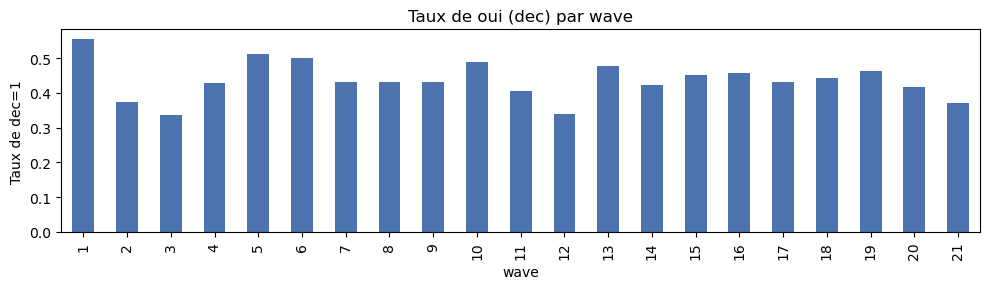

wave
1     0.555
2     0.373
3     0.335
4     0.429
5     0.511
6     0.500
7     0.430
8     0.430
9     0.430
10    0.488
11    0.404
12    0.339
13    0.478
14    0.422
15    0.452
16    0.458
17    0.432
18    0.444
19    0.462
20    0.417
21    0.370


In [5]:
print("Taux de oui global :", round(data["dec"].mean(), 3))

rate_by_wave = data.groupby("wave")["dec"].mean().round(3)
ax = rate_by_wave.plot(kind="bar", figsize=(10, 3), color="#4C72B0")
ax.set_ylabel("Taux de dec=1")
ax.set_xlabel("wave")
ax.set_title("Taux de oui (dec) par wave")
plt.tight_layout()
plt.show()

print(rate_by_wave.to_string())


## 3. Vérification anti-fuite

On vérifie par construction que `FEATURES` ne contient que des variables provenant du questionnaire pré-rendez-vous (`num_base`), d'un one-hot d'une catégorielle whitelistée (`field_cd`, `career_c`, `goal`), ou d'une variable dérivée explicitement connue (`age_diff`, `fit_score`, `income_missing_*`, ...). C'est une vérification par **liste blanche** (plus robuste qu'une liste noire de mots-clés) : toute variable qui ne peut pas être rattachée à l'une de ces trois origines fait échouer l'assert.

On ajoute une seconde vérification complémentaire, par mots-clés connus de variables post-rendez-vous (`attr_o`, `dec_o`, `match`, `like`, `prob`, `met`, `_2`, `_3`, `_s`), en excluant explicitement les dummies de catégorielles (dont les suffixes numériques comme `field_cd_A_2` matcheraient sinon par coïncidence).


In [6]:
num_base = [c for c in OTHER if c not in CAT] + INTERESTS + PREFS + SELF
known_engineered = {"int_corr", "age_diff", "abs_age_diff", "fit_score",
                     "income_missing_A", "income_missing_B"}
dummy_prefixes = tuple(f"{c}_{side}_" for c in CAT for side in "AB")

def is_whitelisted(col):
    if col in known_engineered:
        return True
    if col.startswith(dummy_prefixes):
        return True
    if col.endswith(("_A", "_B")) and col[:-2] in num_base:
        return True
    return False

violations = [c for c in FEATURES if not is_whitelisted(c)]
assert not violations, f"Variables non whitelistées dans FEATURES : {violations}"
print(f"OK (liste blanche) -- les {len(FEATURES)} variables de FEATURES proviennent toutes "
      f"du questionnaire pré-rendez-vous, d'un one-hot whitelisté, ou d'une variable engineered connue.")

POST_DATE_KEYWORDS = ["attr_o", "sinc_o", "intel_o", "fun_o", "amb_o", "shar_o", "like", "prob",
                      "met", "dec_o", "match", "match_es", "_2", "_3", "_s", "satis_2", "numdat_2"]
suspicious = [c for c in FEATURES if any(k in c for k in POST_DATE_KEYWORDS) and c not in known_engineered]
suspicious = [c for c in suspicious if not c.startswith(dummy_prefixes)]
assert not suspicious, f"Colonnes suspectes détectées : {suspicious}"
print("OK (liste noire de mots-clés) -- aucune variable post-rendez-vous détectée.")


OK (liste blanche) -- les 164 variables de FEATURES proviennent toutes du questionnaire pré-rendez-vous, d'un one-hot whitelisté, ou d'une variable engineered connue.
OK (liste noire de mots-clés) -- aucune variable post-rendez-vous détectée.


## 4. Dérive de protocole entre waves

Le protocole de collecte a changé entre sessions : les waves 6 à 9 ont noté les préférences (`attr1_1`...`shar1_1`, ce que le participant recherche chez un partenaire) sur une échelle 1-10 indépendante par attribut, alors que toutes les autres waves les ont notées en répartissant 100 points entre les 6 attributs (contrainte de somme = 100). `load_and_clean()` renormalise déjà les waves 6-9 en parts de 100 (voir `src/build_dataset.py`). On vérifie ici que cette correction a bien fonctionné, puis on élargit la recherche à d'autres variables numériques pour détecter d'éventuelles dérives non encore documentées.


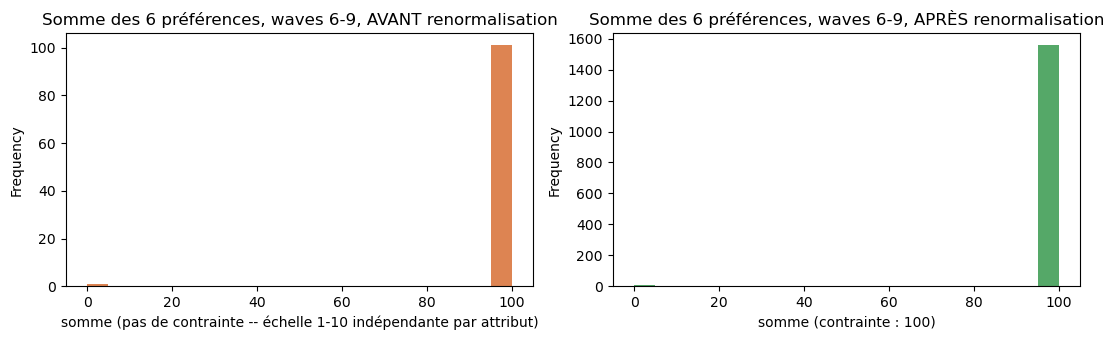

Avant : somme min=0.0 max=100.0
Après : somme min=0.0 max=100.0


In [7]:
raw_prof = raw[["iid", "wave"] + PREFS].drop_duplicates("iid")
waves_69_raw = raw_prof[raw_prof["wave"].between(6, 9)]
sum_before = waves_69_raw[PREFS].sum(axis=1)

cleaned_69 = data[data["wave"].between(6, 9)]
sum_after = cleaned_69[[f"{p}_A" for p in PREFS]].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sum_before.plot(kind="hist", bins=20, ax=axes[0], color="#DD8452")
axes[0].set_title("Somme des 6 préférences, waves 6-9, AVANT renormalisation")
axes[0].set_xlabel("somme (pas de contrainte -- échelle 1-10 indépendante par attribut)")

sum_after.plot(kind="hist", bins=20, ax=axes[1], color="#55A868")
axes[1].set_title("Somme des 6 préférences, waves 6-9, APRÈS renormalisation")
axes[1].set_xlabel("somme (contrainte : 100)")
plt.tight_layout()
plt.show()

print(f"Avant : somme min={sum_before.min():.1f} max={sum_before.max():.1f}")
print(f"Après : somme min={sum_after.min():.1f} max={sum_after.max():.1f}")


In [8]:
print("=== Recherche de dérives non documentées (min/max par wave, variables numériques hors PREFS) ===")
cols_to_check = [f"{c}_A" for c in [c for c in OTHER if c not in CAT] + INTERESTS + SELF]
flagged = []
for c in cols_to_check:
    g = data.groupby("wave")[c].agg(["min", "max"])
    vmax, vmin_of_max = g["max"].max(), g["max"].min()
    if vmax > 0 and vmin_of_max > 0 and (vmax / vmin_of_max) > 3:
        flagged.append(c)
        print(f"{c} : max par wave de {vmin_of_max:.1f} à {vmax:.1f} (ratio {vmax / vmin_of_max:.1f}x) -- À VÉRIFIER")

if not flagged:
    print("Aucune autre dérive de ce type détectée sur les variables numériques du questionnaire pré-rendez-vous.")


=== Recherche de dérives non documentées (min/max par wave, variables numériques hors PREFS) ===
Aucune autre dérive de ce type détectée sur les variables numériques du questionnaire pré-rendez-vous.


**Wave 13** est un cas différent, à ne pas confondre avec la dérive des waves 6-9 : ce n'est pas un problème d'échelle mais une **absence totale de collecte** de la variable `income` pour cette session (100% de manquant, voir section 6). Il n'y a donc rien à renormaliser ici — seulement une gestion spécifique de `income` pour cette wave, implémentée via l'indicateur `income_missing_A`/`income_missing_B` (section 6), pas une correction de valeur comme pour les préférences.

**Conclusion** : la correction de dérive (waves 6-9) est faite **une seule fois, en amont**, dans `load_and_clean()` — toutes les waves alimentent ensuite le même pipeline et le même modèle unique. Il n'y a **pas de segmentation par wave** dans la modélisation ; le wave sert uniquement de variable de groupe pour le split et la validation croisée (section 9), jamais de sous-population à modéliser séparément.


## 5. Structure des waves

Taille et composition en genre de chaque wave (session), pour repérer d'éventuelles waves à la composition atypique (déséquilibre H/F, ou effectif très réduit limitant la puissance statistique de toute analyse par wave, ex. stabilité de Rémi).


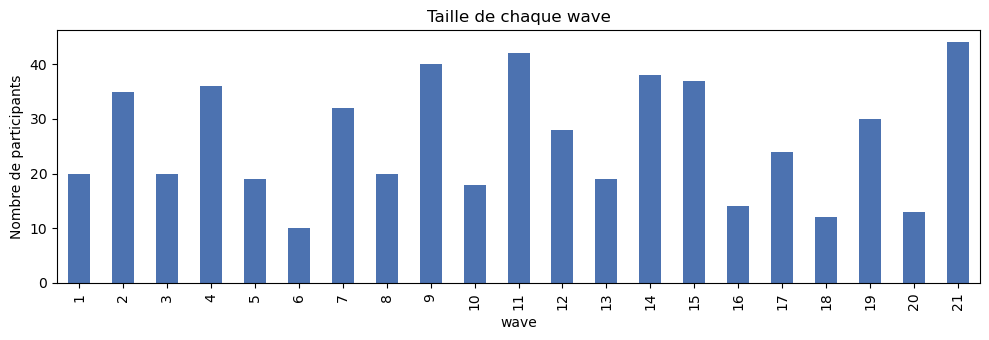

       n  n_hommes  n_femmes  ratio_H_F
wave                                   
1     20        10        10       1.00
2     35        16        19       0.84
3     20        10        10       1.00
4     36        18        18       1.00
5     19        10         9       1.11
6     10         5         5       1.00
7     32        16        16       1.00
8     20        10        10       1.00
9     40        20        20       1.00
10    18         9         9       1.00
11    42        21        21       1.00
12    28        14        14       1.00
13    19         9        10       0.90
14    38        18        20       0.90
15    37        19        18       1.06
16    14         8         6       1.33
17    24        14        10       1.40
18    12         6         6       1.00
19    30        15        15       1.00
20    13         7         6       1.17
21    44        22        22       1.00

Waves à composition atypique (ratio H/F hors [0.7, 1.4] ou effectif < 15) :
   

In [9]:
uniq = data.drop_duplicates("iid")[["iid", "wave", "gender_A"]]
wave_stats = uniq.groupby("wave").agg(n=("iid", "size"), n_hommes=("gender_A", "sum"))
wave_stats["n_femmes"] = wave_stats["n"] - wave_stats["n_hommes"]
wave_stats["ratio_H_F"] = (wave_stats["n_hommes"] / wave_stats["n_femmes"]).round(2)

fig, ax = plt.subplots(figsize=(10, 3.5))
wave_stats["n"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Nombre de participants")
ax.set_title("Taille de chaque wave")
plt.tight_layout()
plt.show()

print(wave_stats.to_string())

atypiques = wave_stats[(wave_stats["ratio_H_F"] < 0.7) | (wave_stats["ratio_H_F"] > 1.4) | (wave_stats["n"] < 15)]
print("\nWaves à composition atypique (ratio H/F hors [0.7, 1.4] ou effectif < 15) :")
print(atypiques.to_string() if not atypiques.empty else "aucune")


## 6. Missingness

Vue d'ensemble du manquant par variable, avec un focus sur `fit_score` et `income_A`/`income_B` (les plus concernées parmi les variables d'entrée), et vérification que le manquant d'`income` n'est pas concentré par wave (sauf exception documentée : wave 13).


In [10]:
base_cols = [c for c in data.columns if not any(c.startswith(p) for p in dummy_prefixes)]
missing_pct = (data[base_cols].isna().mean() * 100).sort_values(ascending=False)
missing_table = missing_pct[missing_pct > 0].round(2).to_frame("% manquant")
print(f"{len(missing_table)} variables avec du manquant sur {len(base_cols)} colonnes non-dummies :")
print(missing_table.to_string())


83 variables avec du manquant sur 94 colonnes non-dummies :
              % manquant
income_A           48.94
income_B           48.94
fit_score           2.41
abs_age_diff        2.25
age_diff            2.25
int_corr            1.89
career_c_A          1.65
career_c_B          1.65
shar1_1_A           1.42
shar1_1_B           1.42
attr3_1_A           1.25
sinc3_1_A           1.25
intel3_1_A          1.25
fun3_1_A            1.25
amb3_1_A            1.25
attr3_1_B           1.25
sinc3_1_B           1.25
intel3_1_B          1.25
fun3_1_B            1.25
amb3_1_B            1.25
exphappy_A          1.21
exphappy_B          1.21
date_B              1.16
amb1_1_B            1.16
date_A              1.16
amb1_1_A            1.16
age_B               1.12
age_A               1.12
fun1_1_A            1.05
fun1_1_B            1.05
field_cd_B          0.98
field_cd_A          0.98
shopping_A          0.94
concerts_B          0.94
dining_B            0.94
museums_B           0.94
art_B          

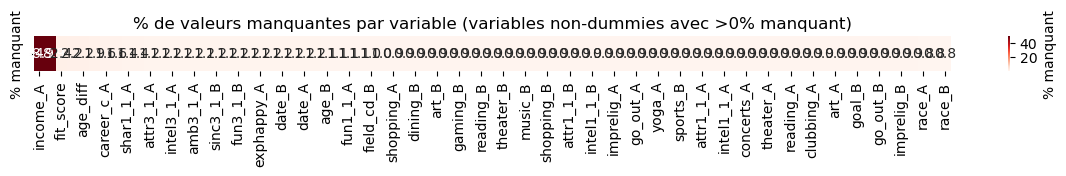

In [11]:
fig, ax = plt.subplots(figsize=(12, 1.8))
sns.heatmap(missing_table.T, annot=True, fmt=".1f", cmap="Reds",
            cbar_kws={"label": "% manquant"}, ax=ax)
ax.set_title("% de valeurs manquantes par variable (variables non-dummies avec >0% manquant)")
plt.tight_layout()
plt.show()


In [12]:
for col in ["fit_score", "income_A", "income_B"]:
    print(f"% manquant {col} : {data[col].isna().mean() * 100:.2f}%")


% manquant fit_score : 2.41%
% manquant income_A : 48.94%
% manquant income_B : 48.94%


Waves à 0%/100% de manquant sur income : {13: 100.0}
Les 20 autres waves varient en continu entre 22.6% et 60.0% -- pas de pattern tout-ou-rien.


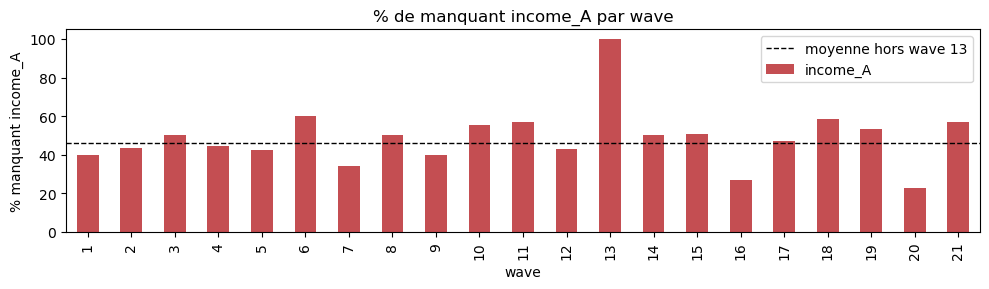

In [13]:
by_wave = data.groupby("wave")["income_A"].apply(lambda s: s.isna().mean() * 100)
full_waves = by_wave[(by_wave == 0) | (by_wave == 100)]
other_waves = by_wave.drop(full_waves.index)

print("Waves à 0%/100% de manquant sur income :", full_waves.round(1).to_dict())
print(f"Les {len(other_waves)} autres waves varient en continu entre "
      f"{other_waves.min():.1f}% et {other_waves.max():.1f}% -- pas de pattern tout-ou-rien.")

fig, ax = plt.subplots(figsize=(10, 3))
by_wave.plot(kind="bar", ax=ax, color="#C44E52")
ax.axhline(other_waves.mean(), color="black", linestyle="--", linewidth=1, label="moyenne hors wave 13")
ax.set_ylabel("% manquant income_A")
ax.set_title("% de manquant income_A par wave")
ax.legend()
plt.tight_layout()
plt.show()


**Recommandations feature engineering issues de l'EDA**

- Le manquant d'`income` (~47% en moyenne hors wave 13) n'est ni concentré sur quelques waves (sauf l'exception wave 13, 100% — blackout complet de la collecte pour cette session), ni un pur hasard : le dictionnaire de données précise que *"When there is no income it means that they are either from abroad or did not enter their zip code"* — c'est donc un manquant lié à des caractéristiques individuelles (étudiant international, non-réponse au zip code), potentiellement informatif.
- **Décision** : créer `income_missing_A`/`income_missing_B`, un indicateur binaire de non-réponse, pour que le modèle puisse exploiter ce signal séparément de la valeur imputée. **Implémenté** dans `engineer_features()` (`src/build_dataset.py`), pas seulement documenté ici — ces deux colonnes sont déjà dans `FEATURES` (vérifiable ci-dessous).
- **Wave 13** est gérée par ce même indicateur (il vaudra 1 pour toute la wave), sans traitement séparé nécessaire — pas de renormalisation possible pour cette wave puisqu'il n'y a aucune valeur collectée à corriger, contrairement aux waves 6-9 (section 4).
- `fit_score` (~2,4% de manquant) reste géré par l'imputation médiane standard du pipeline (section 7 de `01_data_models_v0.py`) — le volume est trop faible pour justifier un traitement spécifique.


In [14]:
print("income_missing_A" in FEATURES, "income_missing_B" in FEATURES)
data[["income_missing_A", "income_missing_B"]].mean().round(3)


True True


income_missing_A    0.489
income_missing_B    0.489
dtype: float64

## 7. income_A / income_B — proxy potentiel

`income_A`/`income_B` est le **revenu médian du zip code déclaré** par le participant (source : Census Bureau, cf. `docs/data_dictionary.md`), **pas un revenu individuel**. On teste si cette variable est un proxy géographique de l'origine (`race_A`/`cand_race`), ce qui en ferait une variable à surveiller de près pour l'audit fairness (FPDP, mitigation — bloc de Blanquette).

On dédoublonne sur individus uniques (`drop_duplicates` sur `iid` pour A, sur `pid` pour B) avant de tester le lien avec la race **du même individu** (`income_A ~ race_A`, `income_B ~ cand_race`) : dans `data`, chaque individu apparaît une fois par candidat rencontré (~15 lignes par personne dans une wave), avec la même valeur d'income répétée à chaque ligne — tester directement sur les paires violerait l'indépendance des observations (pseudo-réplication). Les deux tests de contrôle (`income_A ~ cand_race`, `income_B ~ race_A`, qui testent le lien avec la race **du partenaire**, laquelle varie à chaque ligne pour un même individu) restent eux au niveau des paires, faute d'unité "individu" pertinente pour ces deux-là.


In [15]:
def anova_eta(sub, group_col, value_col):
    groups = [g[value_col].values for _, g in sub.groupby(group_col)]
    f_stat, p_val = stats.f_oneway(*groups)
    grand_mean = sub[value_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((sub[value_col] - grand_mean) ** 2).sum()
    eta_sq = ss_between / ss_total
    means = sub.groupby(group_col)[value_col].agg(["mean", "count"]).round(0)
    means.index = means.index.map(lambda x: RACE_LABELS.get(int(x), x))
    return f_stat, p_val, eta_sq, means


uniq_A = data.drop_duplicates("iid")[["iid", "race_A", "income_A"]].dropna()
uniq_B = data.drop_duplicates("pid")[["pid", "cand_race", "income_B"]].dropna()
pairs_ctrl_A = data[["cand_race", "income_A"]].dropna()
pairs_ctrl_B = data[["race_A", "income_B"]].dropna()

tests = [
    ("income_A ~ race_A (individus uniques, dédup iid)", uniq_A, "race_A", "income_A"),
    ("income_A ~ cand_race (contrôle, paires)", pairs_ctrl_A, "cand_race", "income_A"),
    ("income_B ~ cand_race (individus uniques, dédup pid)", uniq_B, "cand_race", "income_B"),
    ("income_B ~ race_A (contrôle, paires)", pairs_ctrl_B, "race_A", "income_B"),
]

anova_results = {}
for label, sub, group_col, value_col in tests:
    f_stat, p_val, eta_sq, means = anova_eta(sub, group_col, value_col)
    print(f"\n{label} [n={sub.shape[0]}]")
    print(f"  F={f_stat:.2f}  p={p_val:.4f}  eta²={eta_sq:.4f}")
    print(means.to_string())
    anova_results[label] = {"F": round(f_stat, 2), "p": round(p_val, 4), "eta_sq": round(eta_sq, 4)}



income_A ~ race_A (individus uniques, dédup iid) [n=281]
  F=2.66  p=0.0333  eta²=0.0371
           mean  count
race_A                
Black   33610.0     18
White   46069.0    175
Latino  40699.0     16
Asian   47899.0     54
Other   45582.0     18

income_A ~ cand_race (contrôle, paires) [n=4253]
  F=0.68  p=0.6060  eta²=0.0006
              mean  count
cand_race                
Black      44051.0    221
White      45211.0   2477
Latino     44897.0    319
Asian      44317.0    971
Other      44349.0    265

income_B ~ cand_race (individus uniques, dédup pid) [n=281]
  F=2.66  p=0.0333  eta²=0.0371
              mean  count
cand_race                
Black      33610.0     18
White      46069.0    175
Latino     40699.0     16
Asian      47899.0     54
Other      45582.0     18

income_B ~ race_A (contrôle, paires) [n=4253]
  F=0.68  p=0.6060  eta²=0.0006
           mean  count
race_A                
Black   44051.0    221
White   45211.0   2477
Latino  44897.0    319
Asian   44317.0 

**Pourquoi le test sur les paires (n=4273) gonfle la significativité** : sans dédoublonnage, chaque individu A compte ~15 fois (une fois par candidat B rencontré dans sa wave), avec exactement la même valeur `income_A`/`race_A` à chaque ligne. L'ANOVA suppose des observations indépendantes ; répéter ~15 fois la même observation viole cette hypothèse (pseudo-réplication) et gonfle artificiellement la statistique F, faisant chuter la p-value bien en dessous de sa vraie valeur. Concrètement, sur `income_A ~ race_A` : F=48.68, p<0.0001 sur les paires, contre F=2.66, p=0.033 sur les 281 individus uniques — la significativité passe de "écrasante" à "à peine significative". L'eta² (taille d'effet, ~0.037-0.044 dans les deux cas) ne bouge presque pas : **l'effet est réel, c'est la confiance statistique qui était surestimée**. C'est le résultat dédoublonné (individus uniques) qui doit être cité dans le rapport/les slides, pas celui sur les paires.


## 8. Attributs protégés

Distribution de `gender_A`/`gender_B` et `race_A`/`cand_race` (confirmation de l'absence de la catégorie "Native American" dans ce dataset), puis vérification automatisée que ces colonnes ne sont jamais utilisées comme variables d'entrée du modèle.


In [16]:
print("gender_A (individus uniques, 0=femme, 1=homme) :")
print(data.drop_duplicates("iid")["gender_A"].value_counts().to_string())

print("\nrace_A (individus uniques, dédup iid) :")
race_counts = data.drop_duplicates("iid")["race_A"].map(RACE_LABELS).value_counts(dropna=False)
print(race_counts.to_string())

print("\ncand_race (individus B uniques, dédup pid) :")
cand_race_counts = data.drop_duplicates("pid")["cand_race"].map(RACE_LABELS).value_counts(dropna=False)
print(cand_race_counts.to_string())

observed = set(race_counts.index.dropna()) | set(cand_race_counts.index.dropna())
missing_categories = set(RACE_LABELS.values()) - observed
print(f"\nCatégories de race jamais observées dans ce dataset : {missing_categories or 'aucune'}")


gender_A (individus uniques, 0=femme, 1=homme) :
gender_A
1    277
0    274

race_A (individus uniques, dédup iid) :
race_A
White     304
Asian     136
Latino     42
Other      37
Black      26
NaN         6

cand_race (individus B uniques, dédup pid) :
cand_race
White     304
Asian     136
Latino     42
Other      37
Black      26
NaN         6

Catégories de race jamais observées dans ce dataset : {'Native Am.'}


In [17]:
overlap = set(PROTECTED) & set(FEATURES)
assert not overlap, f"Attribut(s) protégé(s) présents dans FEATURES : {overlap}"
print(f"OK -- aucun des {len(PROTECTED)} attributs protégés {PROTECTED} n'est dans FEATURES.")


OK -- aucun des 5 attributs protégés ['cand_female', 'cand_race', 'same_race', 'gender_A', 'race_A'] n'est dans FEATURES.


## 9. Validation du split

On rejoue le split par session (wave) de `01_data_models_v0.py` (`GroupShuffleSplit`, seed=42) et on vérifie automatiquement qu'il ne fuit pas, puis on compare le taux de `dec` entre train et test.


In [18]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
tr_idx, te_idx = next(gss.split(data, groups=data["wave"]))
train, test = data.iloc[tr_idx], data.iloc[te_idx]

train_waves, test_waves = set(train["wave"]), set(test["wave"])
assert not (train_waves & test_waves), f"Waves communes train/test : {train_waves & test_waves}"
print(f"OK -- {len(train_waves)} waves train / {len(test_waves)} waves test, aucune wave commune.")

train_ids = set(train["iid"]) | set(train["pid"])
test_ids = set(test["iid"]) | set(test["pid"])
overlap_ids = train_ids & test_ids
assert not overlap_ids, f"{len(overlap_ids)} individus présents en train ET en test : {list(overlap_ids)[:10]}"
print(f"OK -- aucun iid/pid commun entre train ({len(train_ids)} individus) et test ({len(test_ids)} individus).")

rate_train, rate_test = train["dec"].mean(), test["dec"].mean()
print(f"\nTaux de dec=1 -- train : {rate_train:.3f}  |  test : {rate_test:.3f}  "
      f"(écart : {abs(rate_train - rate_test):.3f})")


OK -- 15 waves train / 6 waves test, aucune wave commune.
OK -- aucun iid/pid commun entre train (420 individus) et test (131 individus).

Taux de dec=1 -- train : 0.418  |  test : 0.429  (écart : 0.011)


**Pourquoi cette comparabilité train/test est nécessaire** : un taux de base (`dec`) très différent entre train et test biaiserait la **calibration** du modèle (les probabilités prédites ne seraient plus interprétables comme des probabilités réelles sur le test), fausserait la **validité du seuil optimisé sur le P&L** (un seuil calé sur le taux de base du train ne serait pas transférable au test), et rendrait incohérentes les **comparaisons de disparité de groupe entre modèles** pour l'audit fairness (une différence de taux de oui entre groupes protégés pourrait refléter un déséquilibre train/test plutôt qu'un vrai effet du modèle).


**Architecture de validation retenue** : le split figé ci-dessus (waves de test : voir `data/split.json`) sert de **test set final, jamais retouché** jusqu'au rapport et à la soutenance — ni pour choisir des hyperparamètres, ni pour caler le seuil du P&L, ni pour une éventuelle mitigation fairness. Tout réglage de ce type passe par une validation croisée `GroupKFold` sur les **waves restantes du train uniquement** (section 8 de `01_data_models_v0.py`, `audit_groupkfold_vs_single_split`) — la même mécanique de validation groupée par wave que celle que Rémi utilisera pour l'analyse de stabilité, pas un troisième bloc de validation fixe séparé. Ça évite de "brûler" le test set en le consultant plusieurs fois pendant les réglages, ce qui biaiserait optimistiquement l'évaluation finale.


## 10. Synthèse finale

**Décisions prises et pourquoi**

- **Renormalisation des préférences waves 6-9** (échelle 1-10 -> 100 points) dans `load_and_clean()`, appliquée une fois en amont pour que toutes les waves alimentent le même pipeline/modèle — pas de segmentation par wave en modélisation (section 4).
- **Wave 13 traitée à part pour `income`** : blackout total de collecte (100% manquant), pas une dérive d'échelle — gérée par l'indicateur de missingness, pas de renormalisation possible (sections 4 et 6).
- **`income_missing_A`/`income_missing_B` créés dans `engineer_features()`** : le manquant d'income (~47% hors wave 13) est lié à des caractéristiques individuelles documentées (étudiant international / zip code non renseigné, cf. dictionnaire de données), pas au hasard — le signal "a répondu ou non" est conservé comme feature à part entière (section 6).
- **`income_A`/`income_B` classés "borderline"** dans `features.json` : proxy géographique confirmé de `race_A`/`cand_race` par ANOVA sur individus uniques dédoublonnés (eta²≈0.037-0.044, p=0.033), pas seulement sur les paires bruitées par pseudo-réplication — à surveiller de près pour l'audit fairness (section 7).
- **Aucune fuite d'information détectée** : vérification automatisée par liste blanche + liste noire de mots-clés, 0 violation sur les 164 variables de `FEATURES` (section 3).
- **Split par wave validé** : aucune wave ni aucun individu (`iid`/`pid`) commun entre train et test, taux de `dec` comparable — condition nécessaire pour la calibration, le seuil P&L, et les comparaisons de disparité fairness entre modèles (section 9).
- **Architecture de validation** : test set figé jamais retouché ; tout réglage (hyperparamètres, seuil P&L, mitigation) passe par `GroupKFold` sur les waves du train — même mécanique que la stabilité de Rémi (section 9).

**Points d'attention pour la suite**

- Groupes `Black`/`Latino` très peu représentés parmi les individus uniques (n=16-18) dans les tests income~race — p-value proche du seuil 0.05, à interpréter avec prudence dans l'audit fairness.
- `income_A`/`income_B` restent en entrée du modèle malgré leur statut de proxy potentiel (décision méthodologique à trancher avec Blanquette : les exclure, les garder avec mitigation, ou les garder et documenter le compromis).
- `imprace_A`/`imprace_B` (importance déclarée de l'origine) sont également proxys directs de `race_A`/`race_B` — déjà classées "borderline" avant cette EDA, non ré-auditées statistiquement ici.
- Aucune autre dérive de protocole détectée au-delà des préférences waves 6-9, mais la vérification (section 4) ne couvre que les variables numériques déjà whitelistées dans `num_base` — pas les colonnes brutes non utilisées.
- La liste de variables doit être figée samedi matin (cf. `context.md`) — toute modification de `FEATURES`/`borderline` après cette EDA doit repasser par `src/build_dataset.py` pour rester synchronisée avec `01_data_models_v0.py` et ce notebook.
